In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/depression-surveydataset-for-analysis/final_depression_dataset_1.csv


# This notebook is to build a classifer model to predict the depression for working professional people based on some factors.
There are some steps:
1. Cleaning the datum;
2. Statistical describtion;
3. Feature Engineering;
4. Select suitable model to train;
5. Evaluate the model.

1.Cleaning the datum;

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('/kaggle/input/depression-surveydataset-for-analysis/final_depression_dataset_1.csv')

In [4]:
df.head(5)

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Pooja,Female,37,Ghaziabad,Working Professional,Teacher,NaN,2.0,NaN,NaN,4.0,7-8 hours,Moderate,MA,No,6,2,No,No
1,Reyansh,Male,60,Kalyan,Working Professional,Financial Analyst,NaN,4.0,NaN,NaN,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No
2,Manvi,Female,42,Bhopal,Working Professional,Teacher,NaN,2.0,NaN,NaN,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No
3,Isha,Female,44,Thane,Working Professional,Teacher,NaN,3.0,NaN,NaN,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No
4,Aarav,Male,48,Indore,Working Professional,UX/UI Designer,NaN,4.0,NaN,NaN,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No


In [5]:
df = df[df["Working Professional or Student"] != "Student"]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2054 entries, 0 to 2554
Data columns (total 19 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Name                                   2054 non-null   object 
 1   Gender                                 2054 non-null   object 
 2   Age                                    2054 non-null   int64  
 3   City                                   2054 non-null   object 
 4   Working Professional or Student        2054 non-null   object 
 5   Profession                             1883 non-null   object 
 6   Academic Pressure                      0 non-null      float64
 7   Work Pressure                          2054 non-null   float64
 8   CGPA                                   0 non-null      float64
 9   Study Satisfaction                     0 non-null      float64
 10  Job Satisfaction                       2054 non-null   float64
 11  Sleep Dur

In [7]:
columns_to_drop = ['Name','Working Professional or Student','Academic Pressure', 'CGPA', 'Study Satisfaction']
df = df.drop(columns=columns_to_drop)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2054 entries, 0 to 2554
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 2054 non-null   object 
 1   Age                                    2054 non-null   int64  
 2   City                                   2054 non-null   object 
 3   Profession                             1883 non-null   object 
 4   Work Pressure                          2054 non-null   float64
 5   Job Satisfaction                       2054 non-null   float64
 6   Sleep Duration                         2054 non-null   object 
 7   Dietary Habits                         2054 non-null   object 
 8   Degree                                 2054 non-null   object 
 9   Have you ever had suicidal thoughts ?  2054 non-null   object 
 10  Work/Study Hours                       2054 non-null   int64  
 11  Financial

The Profession column has 171 missing values, which accounts for approximately 8.33% of the total rows.

In [9]:
df["Profession"] = df["Profession"].fillna("Unknown")

2. Statistical describtion;

In [10]:
# Perform basic statistical analysis on the dataset

# 1. General overview of the dataset (numerical and categorical)
summary_statistics = df.describe(include='all')  # Includes all columns

# 2. Count unique values for categorical columns
categorical_columns = ['Gender', 'Dietary Habits', 'Family History of Mental Illness', 'Profession', 'Depression']
categorical_summary = {col: df[col].value_counts() for col in categorical_columns}

# 3. Correlation analysis for numerical columns
numerical_columns = ['Age', 'Work Pressure', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
correlation_matrix = df[numerical_columns].corr()

# Display results
print("Summary Statistics:\n", summary_statistics)
print("\nCategorical Variable Summary:")
for col, values in categorical_summary.items():
    print(f"{col}:\n{values}\n")
print("Correlation Matrix:\n", correlation_matrix)

Summary Statistics:
        Gender          Age    City Profession  Work Pressure  \
count    2054  2054.000000    2054       2054    2054.000000   
unique      2          NaN      30         36            NaN   
top      Male          NaN  Mumbai    Teacher            NaN   
freq     1066          NaN      86        322            NaN   
mean      NaN    42.171860     NaN        NaN       3.021908   
std       NaN    11.461202     NaN        NaN       1.417312   
min       NaN    18.000000     NaN        NaN       1.000000   
25%       NaN    35.000000     NaN        NaN       2.000000   
50%       NaN    43.000000     NaN        NaN       3.000000   
75%       NaN    51.750000     NaN        NaN       4.000000   
max       NaN    60.000000     NaN        NaN       5.000000   

        Job Satisfaction Sleep Duration Dietary Habits    Degree  \
count        2054.000000           2054           2054      2054   
unique               NaN              4              3        27   
top   

3.Feature Engineering;

* I divided the colums into 3 types, numerical, binary classification and non-binary classfication.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2054 entries, 0 to 2554
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 2054 non-null   object 
 1   Age                                    2054 non-null   int64  
 2   City                                   2054 non-null   object 
 3   Profession                             2054 non-null   object 
 4   Work Pressure                          2054 non-null   float64
 5   Job Satisfaction                       2054 non-null   float64
 6   Sleep Duration                         2054 non-null   object 
 7   Dietary Habits                         2054 non-null   object 
 8   Degree                                 2054 non-null   object 
 9   Have you ever had suicidal thoughts ?  2054 non-null   object 
 10  Work/Study Hours                       2054 non-null   int64  
 11  Financial

Standarize the numerial value columns: Standardization and Normalization

In [12]:
from sklearn.preprocessing import StandardScaler

# Standarize the numerial value columns: Standardization and Normalization
numerical_columns = ['Age', 'Work Pressure', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [13]:
from sklearn.preprocessing import LabelEncoder
categorical_columns = ['Gender', 'Family History of Mental Illness','Have you ever had suicidal thoughts ?','Depression']
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
df.head()

,Gender,Age,City,Profession,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,-0.451359,Ghaziabad,Teacher,-0.721194,0.694533,7-8 hours,Moderate,MA,0,0.018323,-0.692545,0,0
1,1,1.555900,Kalyan,Financial Analyst,0.690271,-0.010643,5-6 hours,Unhealthy,B.Com,1,-1.571912,0.722865,1,0
2,0,-0.014999,Bhopal,Teacher,-0.721194,-0.010643,5-6 hours,Moderate,M.Com,0,-1.571912,-0.692545,0,0
3,0,0.159546,Thane,Teacher,-0.015462,1.399708,7-8 hours,Healthy,MD,1,-1.306873,-0.692545,1,0
4,1,0.508634,Indore,UX/UI Designer,0.690271,-0.010643,7-8 hours,Moderate,BE,1,0.018323,1.430570,1,0


In [14]:
# Calculate the value counts and proportions for the "Depression" column
depression_counts = df["Depression"].value_counts(normalize=True) * 100

# Convert to a DataFrame for better readability
depression_summary = depression_counts.reset_index()
depression_summary.columns = ["Depression_Status", "Percentage"]

# Display the results
print(depression_summary)

   Depression_Status  Percentage
0                  0   90.116845
1                  1    9.883155


In [15]:
# One-Hot Encoding with pd.get_dummies
categorical_columns=["Profession", "City", "Sleep Duration", "Dietary Habits", "Degree"]
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

#
encoded_columns = [col for col in df_encoded.columns if col.split('_')[0] in categorical_columns]
df_encoded[encoded_columns] = df_encoded[encoded_columns].astype(int)

df_encoded.head()

,Gender,Age,Work Pressure,Job Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Profession_Accountant,...,Degree_M.Tech,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_PhD
0,0,-0.451359,-0.721194,0.694533,0,0.018323,-0.692545,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,1,1.555900,0.690271,-0.010643,1,-1.571912,0.722865,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,-0.014999,-0.721194,-0.010643,0,-1.571912,-0.692545,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0.159546,-0.015462,1.399708,1,-1.306873,-0.692545,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0.508634,0.690271,-0.010643,1,0.018323,1.430570,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df_encoded['Depression'].sum()

203

4.Select suitable model to train

In [17]:
from sklearn.model_selection import train_test_split

# The label is  'Depression'
X = df_encoded.drop(columns=['Depression'])  # 特征
y = df_encoded['Depression']  # 目标变量

# Split the tranning and test dataum
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# the set size
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1643, 108)
Test set size: (411, 108)


4.1 LogisticRegression and evaluation of the model

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Tranning Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9854014598540146
Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       368
           1       1.00      0.86      0.92        43

    accuracy                           0.99       411
   macro avg       0.99      0.93      0.96       411
weighted avg       0.99      0.99      0.98       411



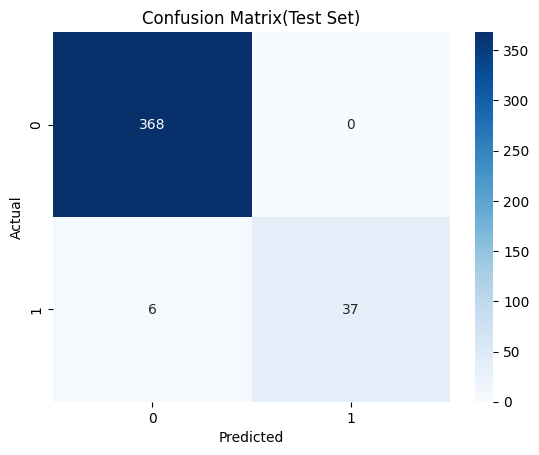

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix(Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

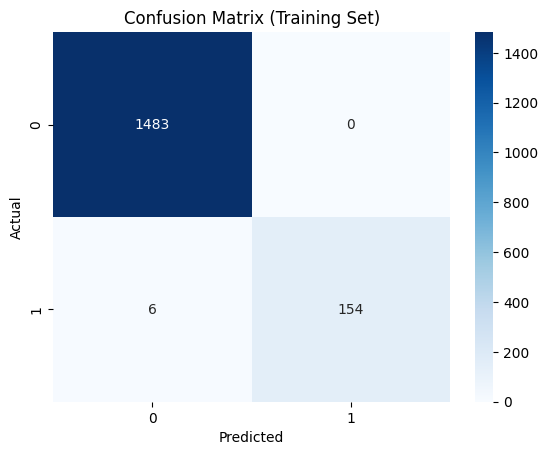

In [23]:
y_train_pred = model.predict(X_train)

cm_train = confusion_matrix(y_train, y_train_pred)

sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Training Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

4.2 RandomForest and evaluation

Test Set Evaluation:
Accuracy: 0.9245742092457421
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96       368
           1       1.00      0.28      0.44        43

    accuracy                           0.92       411
   macro avg       0.96      0.64      0.70       411
weighted avg       0.93      0.92      0.90       411

Training Set Evaluation:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1483
           1       1.00      1.00      1.00       160

    accuracy                           1.00      1643
   macro avg       1.00      1.00      1.00      1643
weighted avg       1.00      1.00      1.00      1643



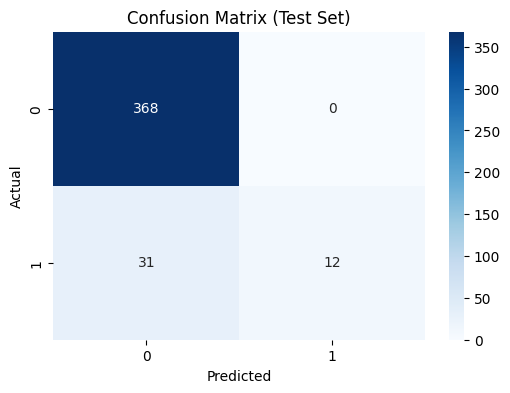

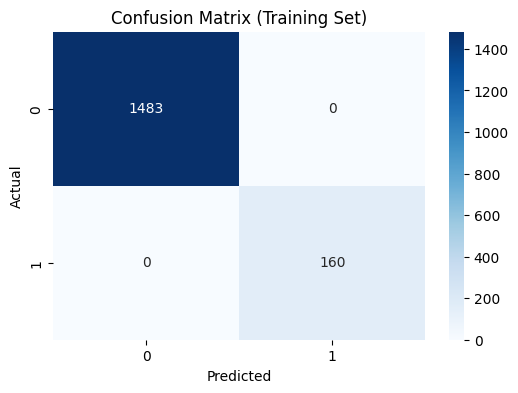

In [26]:
# Import the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForest model
rf_model = RandomForestClassifier(random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Predict on the test set
y_test_pred = rf_model.predict(X_test)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_test_pred = rf_model.predict(X_test)
y_train_pred = rf_model.predict(X_train)


print("Test Set Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


print("Training Set Evaluation:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Classification Report:\n", classification_report(y_train, y_train_pred))


cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Training Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
feature_importances.head(20)

,Feature,Importance
1,Age,0.231557
2,Work Pressure,0.064546
5,Work/Study Hours,0.061395
3,Job Satisfaction,0.060459
4,Have you ever had suicidal thoughts ?,0.056530
6,Financial Stress,0.054800
43,Profession_Unknown,0.021012
76,Sleep Duration_Less than 5 hours,0.018458
92,Degree_Class 12,0.018408
7,Family History of Mental Illness,0.016920
